# Modelación con tres algoritmos

En esta etapa se comparan tres algoritmos para reconocer cuál de las 16 actividades de entrenamiento de REHAB corresponde a cada observación preparada durante el ETL. Todos utilizan exactamente los mismos conjuntos de entrenamiento y prueba para que la comparación sea justa.


## Librerías necesarias

Se utilizarán Pandas y NumPy para cargar los datos, Seaborn y Matplotlib para visualizar los resultados, y Scikit-learn para construir y evaluar los tres clasificadores.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

sns.set_theme(style="white")

Matplotlib is building the font cache; this may take a moment.


## 1. Tipo de problema

El objetivo es predecir la actividad realizada a partir de sus características estadísticas. Como cada observación ya tiene una etiqueta conocida durante el entrenamiento, se trata de **aprendizaje supervisado**. Además, existen 16 etiquetas posibles (`000` a `015`), por lo que el problema es de **clasificación multiclase**.

La salida esperada del modelo es una sola etiqueta de actividad para cada observación de entrada.


## 2. Tipo de datos y modelos compatibles

Después del ETL, cada fila representa una ventana independiente de 220 puntos y contiene **120 características numéricas**: diez estadísticas calculadas para cada uno de los 12 canales de los dos grupos de sensores. La columna `actividad` es categórica y funciona como etiqueta.

Esta estructura corresponde a datos tabulares numéricos. Es compatible con modelos como regresión logística, KNN, SVM, árboles de decisión y Random Forest. En este notebook no se utilizan redes neuronales recurrentes o convolucionales porque esas técnicas suelen trabajar directamente con la secuencia temporal, mientras que aquí los 220 puntos ya fueron resumidos mediante características estadísticas.

Las actividades no tienen exactamente la misma cantidad de observaciones. Por ello, además de la exactitud se utilizará el **F1-score macro**, que calcula el desempeño de cada actividad por separado y después les da el mismo peso.


## 3. Carga de los datos preparados

Se cargarán `datos_train.csv` y `datos_test.csv`. Ambos archivos contienen las 120 características estadísticas y la etiqueta `actividad` como última columna.

Para entrenar los modelos, las características se separarán en `X_train` y `X_test`, mientras que las etiquetas se guardarán en `y_train` y `y_test`. Esta separación no modifica los datos; solamente distingue las entradas de la respuesta que se desea predecir.


In [2]:
# Ruta de la carpeta creada durante el ETL.
RUTA_DATOS_MODELO = Path("../Datos modelo")

# Cargamos ambos conjuntos y conservamos las actividades
# como texto para mantener los ceros iniciales.
datos_train = pd.read_csv(
    RUTA_DATOS_MODELO / "datos_train.csv",
    dtype={"actividad": str}
)

datos_test = pd.read_csv(
    RUTA_DATOS_MODELO / "datos_test.csv",
    dtype={"actividad": str}
)

# Separamos las 120 características de la etiqueta.
X_train = datos_train.drop(columns="actividad").to_numpy()
y_train = datos_train["actividad"].to_numpy()

X_test = datos_test.drop(columns="actividad").to_numpy()
y_test = datos_test["actividad"].to_numpy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Actividades en entrenamiento:", np.unique(y_train).size)
print("Actividades en prueba:", np.unique(y_test).size)

X_train: (12448, 120)
y_train: (12448,)
X_test: (3112, 120)
y_test: (3112,)
Actividades en entrenamiento: 16
Actividades en prueba: 16


### Interpretación

El conjunto de entrenamiento contiene 12,448 observaciones y el conjunto de prueba contiene 3,112. Cada observación tiene 120 características y su correspondiente etiqueta de actividad.

Los dos conjuntos conservan las 16 actividades y las características se encuentran correctamente alineadas con sus etiquetas. El conjunto de prueba permanecerá separado durante el entrenamiento y se utilizará únicamente para medir el desempeño con datos no usados al ajustar los modelos.


## 4. Selección y configuración de los modelos

Se eligieron tres algoritmos con comportamientos distintos para determinar qué tipo de separación describe mejor los datos:

1. **Regresión logística:** se utiliza como modelo base. Busca límites lineales y permite comprobar si las actividades pueden separarse mediante relaciones sencillas entre las características.
2. **SVM con kernel RBF:** puede formar límites no lineales y es adecuado para datos numéricos con varias características. Se incluye para comprobar si relaciones más flexibles mejoran al modelo lineal.
3. **Random Forest:** combina numerosos árboles de decisión y puede aprender relaciones no lineales e interacciones entre características. Es especialmente apropiado para datos tabulares y no exige que todas las variables estén en la misma escala.

La regresión logística y SVM incluyen `StandardScaler` dentro de su pipeline porque ambos algoritmos son sensibles a las diferencias de escala. Random Forest no lo necesita porque sus árboles toman decisiones mediante puntos de corte en cada característica.

Las configuraciones iniciales son las siguientes:

| Modelo | Configuración | Justificación |
|---|---|---|
| Regresión logística | `max_iter=2000` | Da suficientes iteraciones para que el entrenamiento converja. |
| SVM | `kernel='rbf'` | Permite relaciones no lineales entre características y actividades. |
| Random Forest | `n_estimators=200` | Usa 200 árboles para obtener una predicción estable sin hacer el ejercicio innecesariamente complejo. |
| Los tres | `class_weight='balanced'` | Compensa las diferencias en la cantidad de observaciones por actividad durante el entrenamiento. |
| Los tres | `random_state=42` cuando está disponible | Permite reproducir los resultados. |

En esta primera comparación no se realiza una búsqueda automática de hiperparámetros. Se mantienen configuraciones controladas para comparar los tipos de modelo; posteriormente se podrá ajustar únicamente el algoritmo seleccionado.


In [3]:
# Modelo 1: Regresión logística con estandarización.
modelo_logistico = Pipeline([
    ("escalado", StandardScaler()),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# Modelo 2: SVM con kernel no lineal y estandarización.
modelo_svm = Pipeline([
    ("escalado", StandardScaler()),
    (
        "modelo",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=42
        )
    )
])

# Modelo 3: Random Forest.
modelo_random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# El diccionario permite recorrer los tres modelos usando
# exactamente el mismo procedimiento.
modelos = {
    "Regresión logística": modelo_logistico,
    "SVM": modelo_svm,
    "Random Forest": modelo_random_forest
}

print("Modelos preparados:")
for nombre in modelos:
    print("-", nombre)

Modelos preparados:
- Regresión logística
- SVM
- Random Forest


### Resultado de la configuración

Se prepararon los tres modelos solicitados. El escalado quedó integrado solamente en los pipelines de regresión logística y SVM, por lo que se aprende usando el conjunto de entrenamiento y se aplica de la misma forma al conjunto de prueba.


## 5. Entrenamiento y comparación

Cada modelo se ajustará únicamente con `X_train` y `y_train`. Después generará una predicción para cada fila de `X_test`, cuyas etiquetas reales no participaron en el entrenamiento.

Se calcularán tres métricas:

- **Exactitud:** proporción total de observaciones clasificadas correctamente.
- **Precisión macro:** promedio de la precisión de las 16 actividades, dando el mismo peso a cada una. Indica qué proporción de las predicciones asignadas a cada actividad fue correcta.
- **F1-score macro:** promedio del F1 de las 16 actividades, asignando la misma importancia a cada una aunque tengan cantidades diferentes de observaciones.

El modelo más adecuado será el que muestre el mejor desempeño conjunto, dando especial atención al F1-score macro para evitar elegir uno que funcione bien solamente en las actividades con más datos.


In [4]:
# Guardaremos el resumen y las predicciones de cada modelo.
resultados_modelos = []
predicciones_modelos = {}

for nombre, modelo in modelos.items():

    print(f"\nEntrenando: {nombre}")

    # Ajustamos el modelo únicamente con entrenamiento.
    modelo.fit(X_train, y_train)

    # Generamos una predicción directa para cada observación.
    y_pred = modelo.predict(X_test)

    exactitud = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    resultados_modelos.append({
        "modelo": nombre,
        "exactitud": exactitud,
        "precision_macro": precision_macro,
        "f1_macro": f1_macro
    })

    predicciones_modelos[nombre] = y_pred

    print(f"Exactitud: {exactitud:.4f}")
    print(f"Precisión macro: {precision_macro:.4f}")
    print(f"F1-score macro: {f1_macro:.4f}")

# Tabla comparativa final.
tabla_resultados = pd.DataFrame(resultados_modelos)
display(tabla_resultados)


Entrenando: Regresión logística


Exactitud: 0.7873
Precisión macro: 0.7760
F1-score macro: 0.7750

Entrenando: SVM


Exactitud: 0.8869
Precisión macro: 0.8817
F1-score macro: 0.8797

Entrenando: Random Forest


Exactitud: 0.9569
Precisión macro: 0.9544
F1-score macro: 0.9529


,modelo,exactitud,precision_macro,f1_macro
0,Regresión logística,0.787275,0.775960,0.774999
1,SVM,0.886889,0.881702,0.879686
2,Random Forest,0.956941,0.954373,0.952875


### Interpretación de la comparación

Los tres modelos fueron evaluados directamente sobre las mismas 3,112 observaciones del conjunto de prueba. No se realizaron agrupaciones ni combinaciones posteriores de predicciones.

La regresión logística obtuvo una exactitud de **78.73%** y un F1-score macro de **0.7750**. Este fue el desempeño más bajo, lo que indica que los límites lineales no representan suficientemente las diferencias entre las actividades.

SVM alcanzó una exactitud de **88.69%** y un F1-score macro de **0.8797**. La mejora frente a la regresión logística muestra que las relaciones entre las características y las actividades son, al menos en parte, no lineales.

Random Forest obtuvo el mejor resultado, con una exactitud de **95.69%** y un F1-score macro de **0.9529**. La cercanía entre ambas métricas indica que el desempeño no se concentra únicamente en las actividades con más observaciones.


## 6. Evaluación detallada del modelo seleccionado

La comparación anterior permite seleccionar **Random Forest**. Para revisar que su desempeño sea consistente entre las 16 actividades, se mostrará el reporte de clasificación con precisión, recall y F1-score por clase, además de una matriz de confusión.

En la matriz, las filas representan las actividades reales y las columnas las predicciones. Los valores de la diagonal son aciertos; los valores fuera de ella muestran qué actividades confunde el modelo.


,precision,recall,f1-score,support
000,1.0000,0.9931,0.9965,144.0000
001,0.8790,0.9079,0.8932,152.0000
002,0.8864,0.8603,0.8731,136.0000
003,0.9744,0.9500,0.9620,160.0000
004,0.9953,0.9727,0.9839,220.0000
005,0.9696,0.9955,0.9824,224.0000
006,0.9040,0.9524,0.9275,168.0000
007,0.9808,0.9968,0.9887,308.0000
008,0.9912,0.9417,0.9658,240.0000
009,0.9336,0.9795,0.9560,244.0000


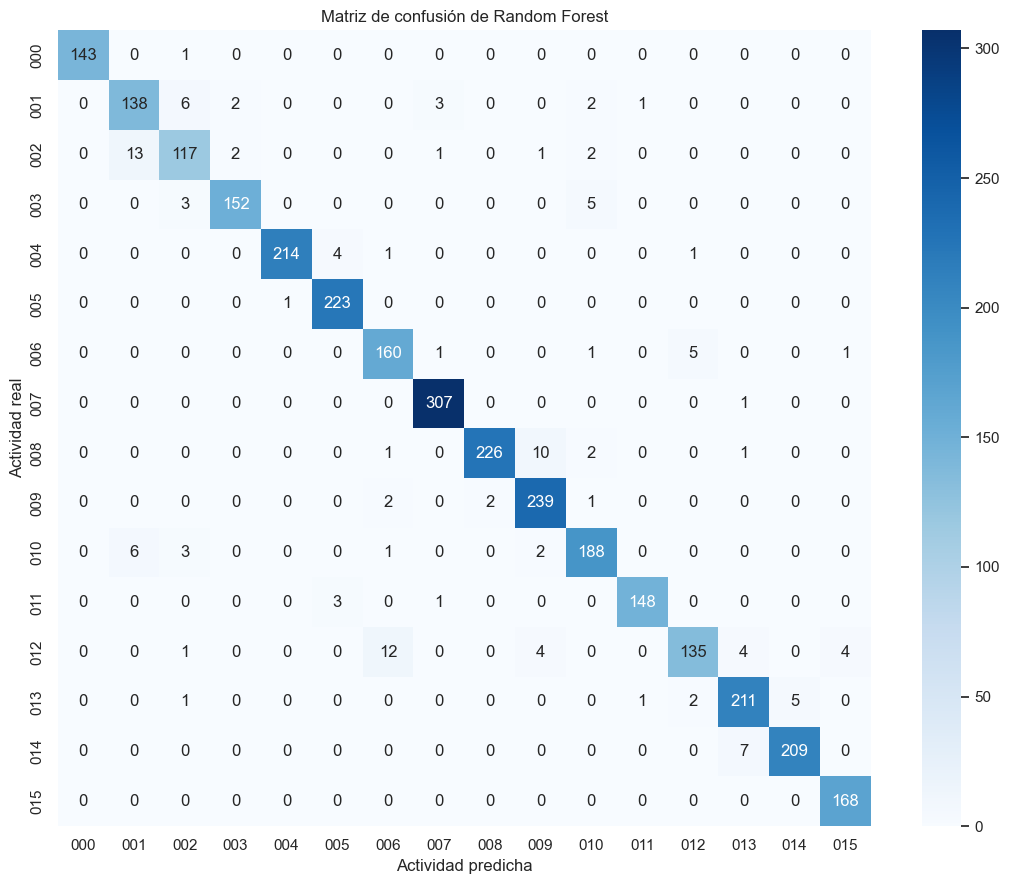

In [5]:
# Recuperamos las predicciones del modelo con mejor resultado.
predicciones_rf = predicciones_modelos["Random Forest"]
actividades = np.sort(np.unique(y_test))

# Creamos el reporte de métricas para cada actividad.
reporte_rf = classification_report(
    y_test,
    predicciones_rf,
    labels=actividades,
    output_dict=True,
    zero_division=0
)

tabla_reporte_rf = pd.DataFrame(reporte_rf).transpose()
display(tabla_reporte_rf.round(4))

# Calculamos y mostramos la matriz de confusión.
matriz_rf = confusion_matrix(
    y_test,
    predicciones_rf,
    labels=actividades
)

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actividades,
    yticklabels=actividades
)
plt.title("Matriz de confusión de Random Forest")
plt.xlabel("Actividad predicha")
plt.ylabel("Actividad real")
plt.tight_layout()
plt.show()


### Interpretación de la evaluación detallada

El reporte confirma que el desempeño es alto en la mayoría de las actividades y que los aciertos se concentran en la diagonal de la matriz. La actividad `000` alcanzó un F1-score de **0.9965**, mientras que `003`, `004`, `005`, `007`, `008`, `011`, `014` y `015` superaron **0.96**.

Las actividades que requieren mayor atención son `002`, con el F1-score más bajo (**0.8731**), y `012`, con el recall más bajo (**0.8438**). Esto significa que Random Forest todavía pierde una proporción mayor de ejemplos reales de `012`. La matriz de confusión permite ubicar hacia qué actividades se desvían esos casos y orientar cambios posteriores en las características o en los parámetros del modelo.


## 7. Decisión final

Con las configuraciones evaluadas, **Random Forest es el modelo seleccionado** porque obtuvo la mayor exactitud (**95.69%**) y el mayor F1-score macro (**0.9529**). También es compatible con la estructura tabular de las 120 características y puede representar las relaciones no lineales que la regresión logística no logró capturar.

Esta conclusión se limita a la comparación inicial sobre el conjunto de prueba disponible. Como siguiente etapa, los ajustes de hiperparámetros deberán hacerse mediante validación cruzada usando únicamente los datos de entrenamiento; el conjunto de prueba debe conservarse para la evaluación final.
